# Principal Component Analysis (PCA) using Covariance Matrix

Jonas J. R. Koberschinski  
2026-04-10

## Data import

In [ ]:
#| echo: true
#| include: false

#data set with all CpGs in columns for EDA and PCA
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

# A tibble: 5 × 44
  TraceFileName     ID Standort Zeitpunkt_als_Zahl Zeitpunkt Platte Group Gruppe
  <chr>          <int>    <int>              <int> <chr>     <chr>  <chr> <chr> 
1 BDNF-C1_001_0…     1        0                  1 T0        Pl1    Cont… Contr…
2 BDNF-C1_001_0…     1        0                  2 T1        Pl2    Cont… Contr…
3 BDNF-C1_002_0…     2        0                  1 T0        Pl1    Piano Piano 
4 BDNF-C1_002_0…     2        0                  2 T1        Pl2    Piano Piano 
5 BDNF-C1_002_0…     2        0                  3 T2        Pl3    Piano Piano 
# ℹ 36 more variables: Gruppe_als_zahl <int>, Koordinate <chr>, m148 <dbl>,
#   m111 <dbl>, m087 <dbl>, m066 <dbl>, m058 <dbl>, m039 <dbl>, m035 <dbl>,
#   m024 <dbl>, p018 <dbl>, p020 <dbl>, Code <chr>, Sex <chr>, Age_start <int>,
#   B03a_sleep_quality <int>, B03b_sleep_duration <dbl>,
#   B03c_sleep_to_recover <dbl>, B09a_groesse <int>, B09b_gewicht <dbl>,
#   B14a_rauchen <int>, rauchen <int>, B14d_wie_viel

# A tibble: 5 × 380
  TraceFileName             ID Zeit  ID_Pl4_Zeit VP_plus_zeitpunkt Platte Gruppe
  <chr>                  <int> <chr>       <int>             <int>  <int> <chr> 
1 TAU-C1_1_T0_Pl1_Tau_C…     1 T0              1               101      1 Contr…
2 TAU-C1_1_T1_Pl2_Tau_C…     1 T1              1               102      2 Contr…
3 TAU-C1_2_T0_Pl1_Tau_P…     2 T0              2               201      1 Piano 
4 TAU-C1_2_T1_Pl2_Tau_P…     2 T1              2               202      2 Piano 
5 TAU-C1_2_T2_Pl3_Tau_P…     2 T2              2               203      3 Piano 
# ℹ 373 more variables: Koordinate <chr>, m337 <dbl>, m331 <dbl>, m323 <dbl>,
#   m315 <dbl>, m310 <dbl>, m306 <dbl>, m300 <dbl>, m293 <dbl>, m287 <dbl>,
#   m277 <dbl>, m249 <dbl>, m219 <dbl>, m210 <dbl>, m207 <dbl>, m187 <dbl>,
#   m181 <dbl>, m172 <dbl>, m152 <dbl>, m147 <dbl>, m111 <dbl>, m109 <dbl>,
#   m105 <dbl>, m100 <dbl>, m95 <dbl>, m93 <dbl>, m91 <dbl>, m87 <dbl>,
#   m85 <dbl>, m80 <dbl>, m73 <dbl>

# A tibble: 5 × 376
  TraceFileName             ID Zeitpunkt_als_zahle VP_plus_zeitpunkt ID_Pl4_Zeit
  <chr>                  <int>               <int>             <int>       <int>
1 PSD95-C1_1_T0_Pl1_PSD…     1                   1               101           1
2 PSD95-C1_1_T1_Pl2_PSD…     1                   2               102           1
3 PSD95-C1_2_T0_Pl1_PSD…     2                   1               201           2
4 PSD95-C1_2_T1_Pl2_PSD…     2                   2               202           2
5 PSD95-C1_2_T2_Pl3_PSD…     2                   3               203           2
# ℹ 371 more variables: Zeitpunkt <chr>, Platte <int>, Gruppe <chr>,
#   Koordinate <chr>, m465 <dbl>, m418 <dbl>, m405 <dbl>, m400 <dbl>,
#   m395 <dbl>, m392 <dbl>, m349 <dbl>, m340 <dbl>, m329 <dbl>, m326 <dbl>,
#   m294 <dbl>, m291 <dbl>, m284 <dbl>, m282 <dbl>, m254 <dbl>, m249 <dbl>,
#   m236 <dbl>, m226 <dbl>, m199 <dbl>, m193 <dbl>, m176 <dbl>, m165 <dbl>,
#   m163 <dbl>, m155 <dbl>, m150 <dbl>, m124 <

Raw (unscaled) CpG methylation values. –\>PCA is therefore using the
**covariance matrix** of those CpGs.

Chat: “You can interpret large‐magnitude loadings as CpGs most
responsible for differences among your samples.” Watch out!

## BDNF

### Data selection

In [ ]:
cpg_bdnf <- bdnf[11:20]

### PCA computation

In [ ]:
pca_bdnf <- prcomp(na.omit(cpg_bdnf), scale = FALSE) # Raw (unscaled) methylation values --> PCA with covariance matrix of CpGs
# prcomp() centers by default!
#For CpG methylation data (which often varies by scale and variance across loci): center = TRUE and scale = TRUE are recommended (your current setting is correct).

# Extract principal component scores
pc_scores_bdnf <- as.data.frame(pca_bdnf$x)

### Normality diagnostics

       PC      p_value       BH_adj
PC1   PC1 3.765128e-03 6.275213e-03
PC2   PC2 2.192514e-02 2.436126e-02
PC3   PC3 1.275358e-01 1.275358e-01
PC4   PC4 1.886368e-02 2.357959e-02
PC5   PC5 1.334632e-02 1.906617e-02
PC6   PC6 7.549599e-13 1.509920e-12
PC7   PC7 6.882580e-28 6.882580e-27
PC8   PC8 6.685824e-21 2.228608e-20
PC9   PC9 3.065882e-23 1.532941e-22
PC10 PC10 1.480738e-18 3.701844e-18

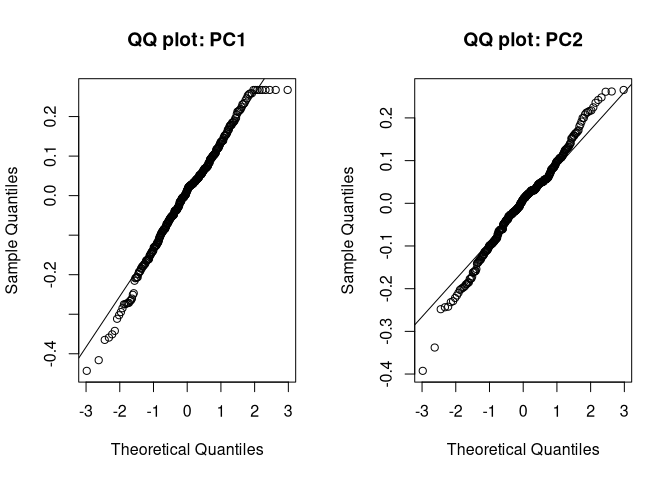

In [ ]:
# Perform Shapiro-Wilk test for normality on each principal component
shapiro_p_bdnf <- sapply(pc_scores_bdnf, function(z) {
  n <- length(z)
  if (n >= 3 && n <= 5000) shapiro.test(z)$p.value else NA_real_
})
shapiro_tab_bdnf <- data.frame(PC = names(shapiro_p_bdnf),
                          p_value = as.numeric(shapiro_p_bdnf),
                          BH_adj = p.adjust(shapiro_p_bdnf, method = "BH"))
print(shapiro_tab_bdnf)

In [ ]:
# Extract principal component scores
pc_scores <- as.data.frame(pca_bdnf$x)

### Visualizations

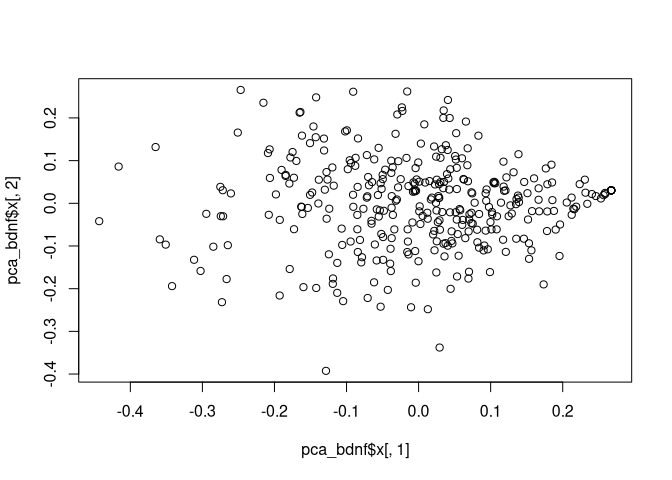

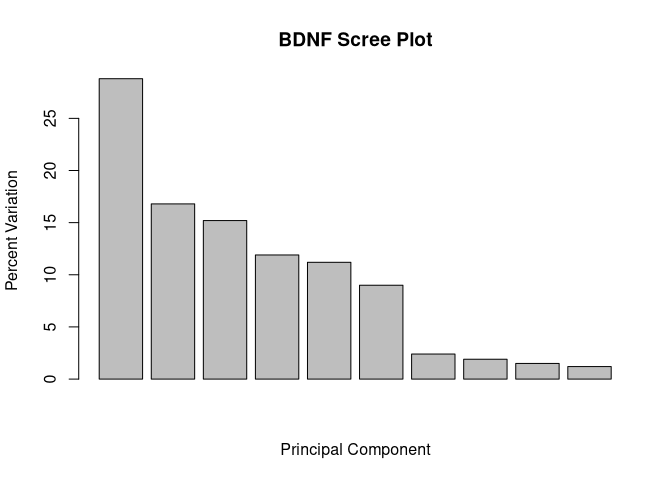

'data.frame':   346 obs. of  10 variables:
 $ PC1 : num  -0.06527 0.10391 -0.0389 0.06767 -0.00851 ...
 $ PC2 : num  -0.0477 0.0494 -0.1065 0.0891 -0.0449 ...
 $ PC3 : num  0.059409 0.000211 -0.048035 -0.152814 -0.040886 ...
 $ PC4 : num  0.10665 0.03918 0.01052 -0.00492 -0.09065 ...
 $ PC5 : num  -0.0439 -0.0295 0.013 0.1485 0.0752 ...
 $ PC6 : num  0.0305 0.0096 0.0596 0.0432 -0.02 ...
 $ PC7 : num  -1.90e-02 -1.51e-02 4.62e-02 -2.05e-02 9.61e-05 ...
 $ PC8 : num  0.0257 0.007 -0.085 0.0199 -0.0204 ...
 $ PC9 : num  -0.00186 0.00147 0.02299 0.00438 -0.00801 ...
 $ PC10: num  0.017602 -0.004057 0.073836 -0.000664 -0.014102 ...

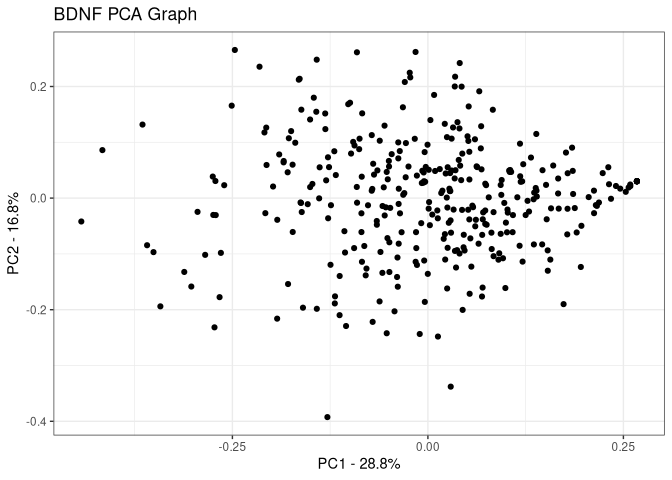

In [ ]:
## plot pc1 and pc2
plot(pca_bdnf$x[,1], pca_bdnf$x[,2])# pca_bdnf$x holds the principal component scores (i.e., the transformed sample coordinates in PC space).

ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ggfortify package.
  Please report the issue at <https://github.com/sinhrks/ggfortify/issues>.

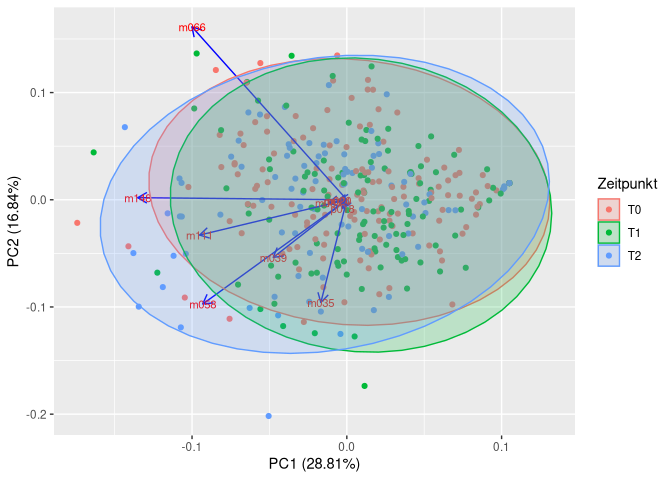

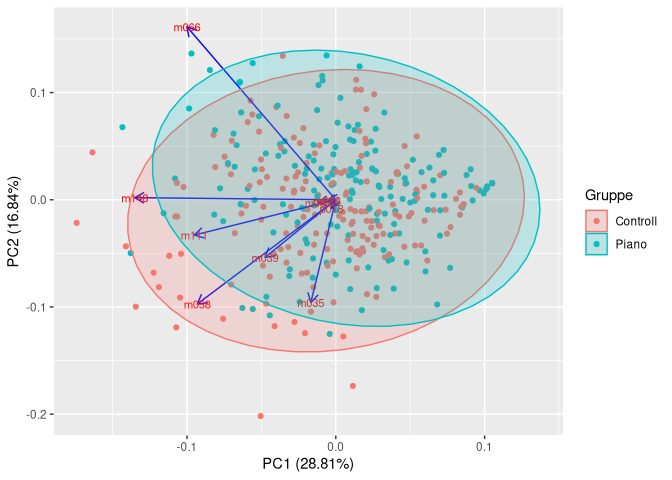

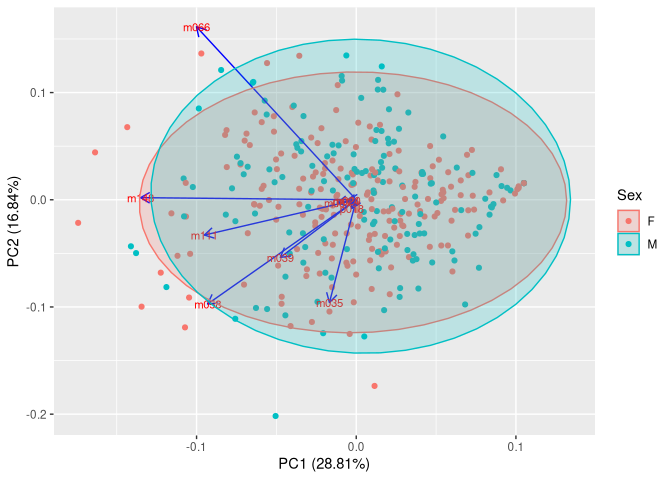

In [ ]:
library(ggfortify)
pca_bdnf_res <- prcomp(na.omit(bdnf[c(11:20)]), scale = FALSE)

autoplot(pca_bdnf_res, data = na.omit(bdnf[c(1:20)]), colour = 'Zeitpunkt',
         loadings = TRUE, loadings.colour = 'blue',
         loadings.label = TRUE, loadings.label.size = 3,
         frame = TRUE, frame.type = "norm"
)

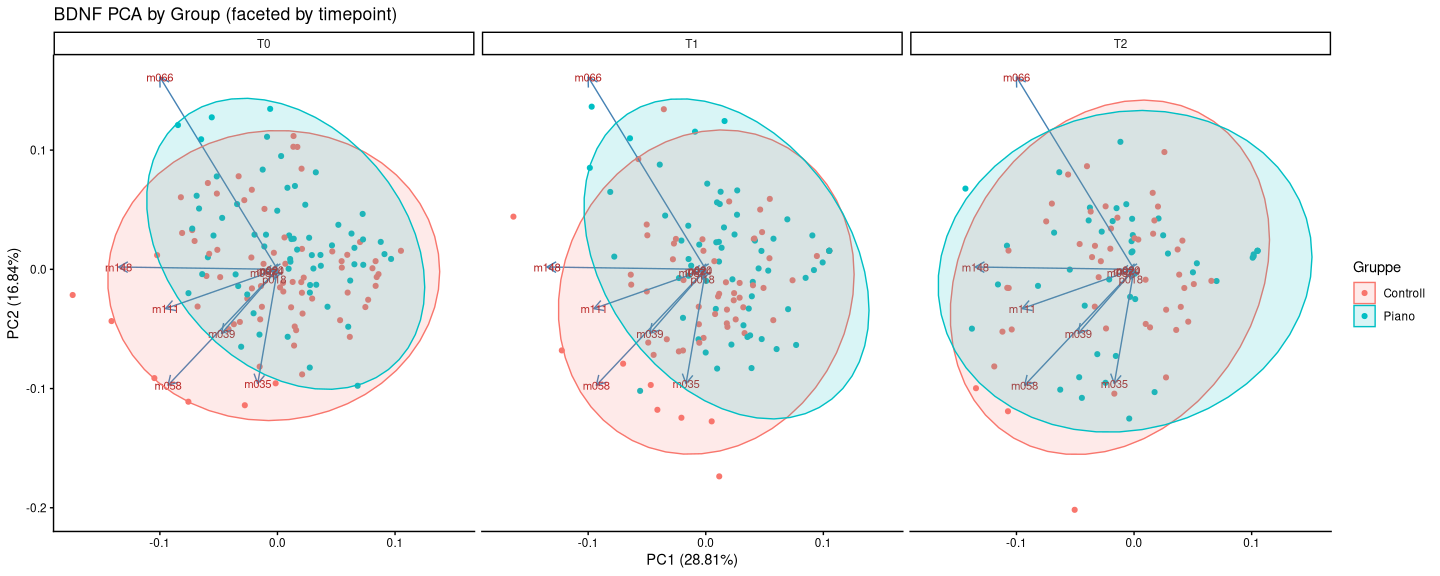

In [ ]:
#| label: fig-bdnf-pca-group-timepoint
#| fig-cap: "BDNF PCA biplot. Points colored by Gruppe, faceted by Zeitpunkt; loadings shown as arrows with labels; 95% normal ellipses per group."
#| fig-width: 15
#| fig-height: 6

library(ggfortify)
library(ggplot2)

bdnf$Age_start <- as.numeric(bdnf$Age_start)
bdnf$CogTel    <- as.numeric(bdnf$CogTel)

autoplot(
  pca_bdnf_res,
  data = na.omit(bdnf[c(1:22)]),
  colour = "Gruppe",
  loadings = TRUE,
  loadings.colour = "steelblue",
  loadings.label = TRUE,
  loadings.label.colour = "firebrick",
  loadings.label.size = 3,
  frame = TRUE,
  frame.type = "norm",
  frame.level = 0.95,
  frame.alpha = 0.15
) +
  scale_size_continuous(range = c(2, 6)) +
  facet_wrap(~Zeitpunkt) +
  theme_classic() +
  labs(title = "BDNF PCA by Group (faceted by timepoint)")

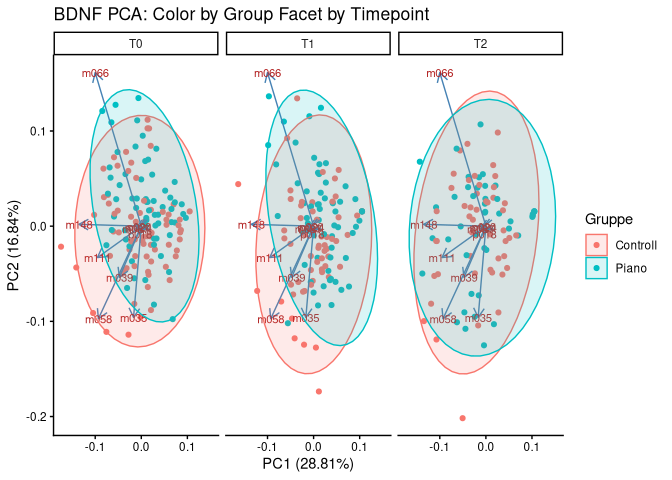

In [ ]:
library(ggfortify)
library(ggplot2)

# Ensure numeric variables for size
bdnf$Age_start <- as.numeric(bdnf$Age_start)
bdnf$CogTel <- as.numeric(bdnf$CogTel)

autoplot(
  pca_bdnf_res,
  data = na.omit(bdnf[c(1:22)]),
  colour = "Gruppe",            # point color by group
  loadings = TRUE,
  loadings.colour = "steelblue",        # <-- arrows
  loadings.label = TRUE,
  loadings.label.colour = "firebrick",  # <-- text labels
  loadings.label.size = 3,
    frame = TRUE,                 # << draw group frames
  frame.type = "norm",          # "norm", "t", or "convex"
  frame.level = 0.95,           # 95% ellipse
  frame.alpha = 0.15            # transparency for overlap
) +
  scale_size_continuous(range = c(2, 6)) +      # min/max point size
  facet_wrap(~Zeitpunkt) +                       # separate panels for each timepoint
  theme_classic() +
  ggtitle("BDNF PCA: Color by Group Facet by Timepoint")

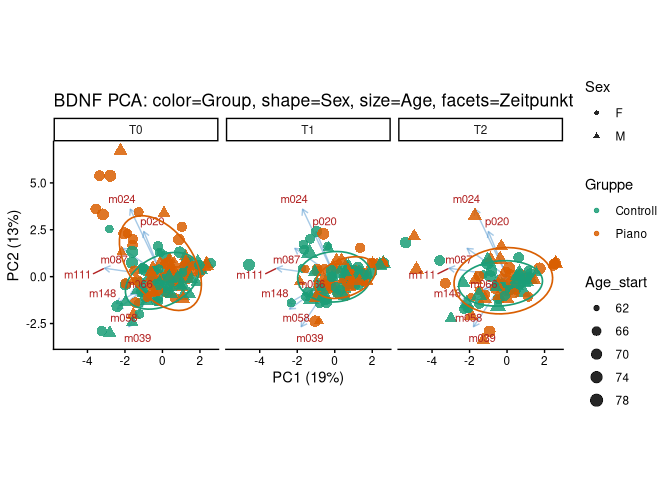

In [ ]:
library(dplyr)
library(ggplot2)
library(ggrepel)

## --- 1) Prepare matched data and run PCA ---
cpg_cols <- which(names(bdnf) == "m148"):which(names(bdnf) == "p020")

X <- bdnf[, cpg_cols] |>
  mutate(across(everything(), ~ suppressWarnings(as.numeric(.))))
keep <- complete.cases(X, bdnf[, c("Gruppe","Sex","Zeitpunkt","Age_start")])
X    <- as.matrix(X[keep, , drop = FALSE])
meta <- bdnf[keep, c("Gruppe","Sex","Zeitpunkt","Age_start")]

pca <- prcomp(X, center = TRUE, scale. = TRUE)

## --- 2) Scores and (shorter) top loadings ---
scores <- as.data.frame(pca$x[, 1:2]) |>
  setNames(c("PC1","PC2")) |>
  bind_cols(meta)

# top 8 loadings, scaled shorter so they don't swamp points
load <- as.data.frame(pca$rotation[, 1:2])
load$CpG <- rownames(load)
load$mag <- sqrt(load$PC1^2 + load$PC2^2)
load_top <- load |> dplyr::slice_max(mag, n = 8)

rng    <- apply(scores[, c("PC1","PC2")], 2, \(z) diff(range(z)))
arrow_scale <- 0.45 * min(rng) / max(abs(as.matrix(load_top[, c("PC1","PC2")])))

load_top_scaled <- transform(load_top,
                             PC1 = PC1 * arrow_scale,
                             PC2 = PC2 * arrow_scale)

## --- 3) Plot: arrows first (light), then points (bigger), then labels ---
ggplot() +
  # arrows BEHIND points
  geom_segment(
    data = load_top_scaled,
    aes(x = 0, y = 0, xend = PC1, yend = PC2),
    color = "steelblue3", linewidth = 0.5, alpha = 0.5,
    arrow = arrow(length = unit(5, "pt"))
  ) +
  # points ON TOP
  geom_point(
    data = scores,
    aes(PC1, PC2, color = Gruppe, shape = Sex, size = Age_start),
    alpha = 0.85, stroke = 0.3
  ) +
  # loadings labels (repelled, small)
  geom_text_repel(
    data = load_top_scaled,
    aes(PC1, PC2, label = CpG),
    size = 3, color = "firebrick", max.overlaps = 50
  ) +
  stat_ellipse(
    data = scores,
    aes(PC1, PC2, color = Gruppe),
    level = 0.68, linewidth = 0.6, type = "norm", show.legend = FALSE
  ) +
  facet_wrap(~ Zeitpunkt) +
  coord_equal() +
  scale_color_brewer(palette = "Dark2") +
  scale_shape_manual(values = c(16, 17)) +
  scale_size_continuous(range = c(1.8, 4.2)) +
  theme_classic() +
  labs(
    title = "BDNF PCA: color=Group, shape=Sex, size=Age, facets=Zeitpunkt",
    x = paste0("PC1 (", scales::percent(summary(pca)$importance[2, 1]), ")"),
    y = paste0("PC2 (", scales::percent(summary(pca)$importance[2, 2]), ")")
  )

### Ranking BDNF loadings

In [ ]:
# Rank CpGs by influence on PC1
ranked_bdnf_cpgs <- sort(abs(bdnf_loading_scores), decreasing =
 TRUE)
head(ranked_bdnf_cpgs)

     m148      m066      m111      m058      m039      m035 
0.6120084 0.4532722 0.4309880 0.4216024 0.2153321 0.0760297 

| Rank | CpG  |       |
|------|------|------:|
| 1    | m148 | 0.612 |
| 2    | m066 | 0.453 |
| 3    | m111 | 0.431 |
| 4    | m058 | 0.422 |
| \-   | —-   |    —– |
| 5    | m039 | 0.215 |
| 6    | m035 | 0.076 |
| 7    | m087 | 0.053 |
| 8    | m024 | 0.029 |
| 9    | p020 | 0.022 |
| 10   | p018 | 0.013 |

### Visualize ranked loadings

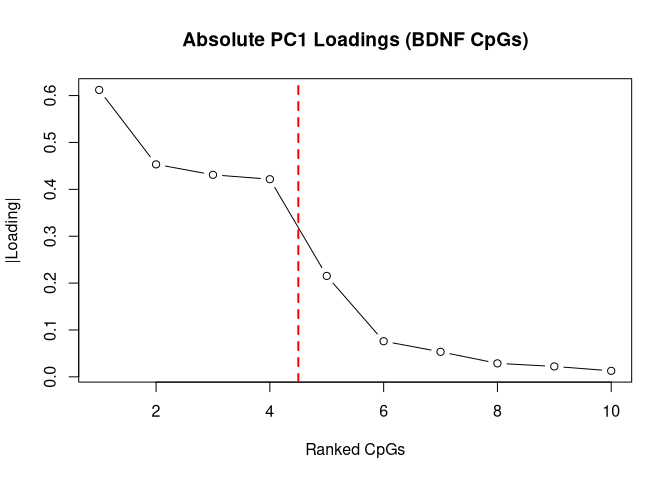

In [ ]:
plot(ranked_bdnf_cpgs, type = "b", main = "Absolute PC1 Loadings (BDNF CpGs)",
     ylab = "|Loading|", xlab = "Ranked CpGs")
abline(v = 4.5, col = "red", lty = 2, lwd = 2)

Die ersten 4 CpG scheinen die wesentlichen zu sein, wie in den Boxplots
zu erkennen!

## Tau

In [ ]:
cpg_tau <- tau[c(9:57)]
pca_tau <- prcomp(na.omit(cpg_tau), scale = FALSE)
# Extract principal component scores
pc_scores_tau <- as.data.frame(pca_tau$x)

       PC      p_value       BH_adj
PC1   PC1 4.880624e-08 1.328614e-07
PC2   PC2 8.490072e-14 1.040034e-12
PC3   PC3 1.585460e-13 1.553751e-12
PC4   PC4 1.432088e-19 7.017233e-18
PC5   PC5 4.161348e-19 1.019530e-17
PC6   PC6 1.730694e-07 3.854727e-07
PC7   PC7 6.850674e-05 9.324529e-05
PC8   PC8 4.001279e-10 1.960627e-09
PC9   PC9 2.317205e-05 3.244087e-05
PC10 PC10 6.372179e-06 9.757399e-06
PC11 PC11 3.870901e-04 4.863439e-04
PC12 PC12 8.909682e-04 1.015289e-03
PC13 PC13 1.418286e-01 1.447833e-01
PC14 PC14 1.229376e-09 5.019953e-09
PC15 PC15 7.414140e-07 1.297474e-06
PC16 PC16 1.566406e-08 5.482420e-08
PC17 PC17 9.243029e-10 4.117349e-09
PC18 PC18 1.079571e-07 2.519000e-07
PC19 PC19 1.137628e-05 1.689206e-05
PC20 PC20 2.294891e-02 2.392546e-02
PC21 PC21 9.626331e-05 1.274838e-04
PC22 PC22 2.047342e-01 2.047342e-01
PC23 PC23 4.730708e-12 3.311495e-11
PC24 PC24 2.687445e-10 1.463165e-09
PC25 PC25 2.100179e-07 4.474295e-07
PC26 PC26 1.901289e-03 2.117345e-03
PC27 PC27 6.712463e-09 2.530

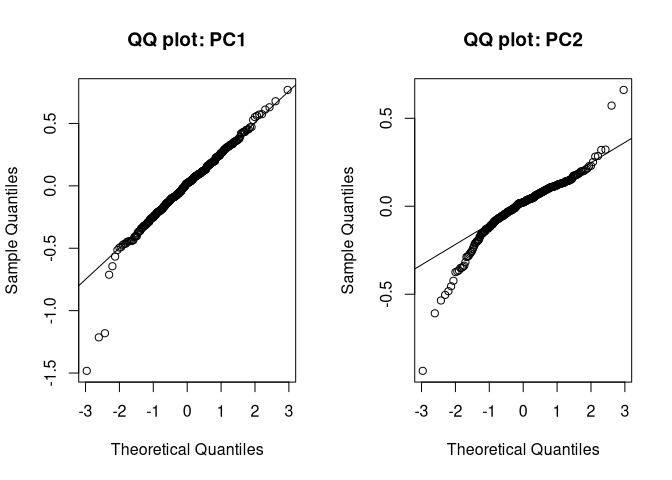

In [ ]:
## Normality diagnostics
# Perform Shapiro-Wilk test for normality on each principal component
shapiro_p_tau <- sapply(pc_scores_tau, function(z) {
  n <- length(z)
  if (n >= 3 && n <= 5000) shapiro.test(z)$p.value else NA_real_
})
shapiro_tab_tau <- data.frame(PC = names(shapiro_p_tau),
                          p_value = as.numeric(shapiro_p_tau),
                          BH_adj = p.adjust(shapiro_p_tau, method = "BH"))
print(shapiro_tab_tau)

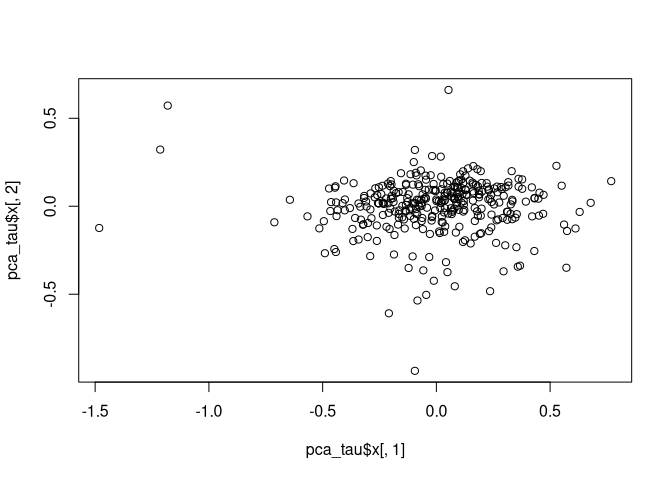

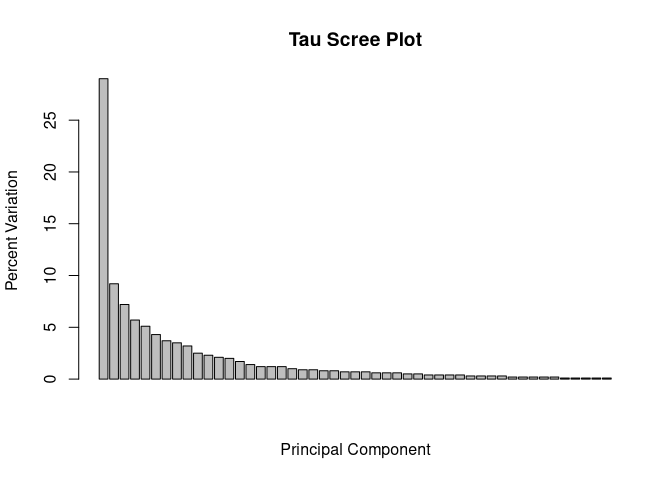

'data.frame':   329 obs. of  49 variables:
 $ PC1 : num  -0.1346 0.0367 -0.2025 0.0235 0.304 ...
 $ PC2 : num  -0.0284 0.0765 -0.0133 -0.0895 0.108 ...
 $ PC3 : num  0.1267 -0.0822 0.1809 0.0221 0.0713 ...
 $ PC4 : num  0.0959 -0.0299 0.1017 0.0112 -0.1309 ...
 $ PC5 : num  -0.0812 0.0395 0.1077 0.0121 0.0898 ...
 $ PC6 : num  -0.0743 0.019 -0.1654 -0.0559 -0.2685 ...
 $ PC7 : num  0.00243 0.02304 0.18851 -0.05205 -0.07119 ...
 $ PC8 : num  0.02904 -0.00748 0.17213 0.01029 0.07147 ...
 $ PC9 : num  -0.0227 -0.0455 0.0954 0.1468 0.0982 ...
 $ PC10: num  0.01364 0.00702 0.10324 -0.08211 0.03125 ...
 $ PC11: num  -0.0364 -0.0548 0.1665 0.0895 0.0189 ...
 $ PC12: num  0.02273 -0.00606 -0.01877 0.01458 0.1518 ...
 $ PC13: num  0.02008 0.03208 0.06899 0.00298 0.07219 ...
 $ PC14: num  -0.02039 0.00108 -0.08481 0.03125 0.01357 ...
 $ PC15: num  -0.00812 0.05888 -0.05753 0.04333 0.06131 ...
 $ PC16: num  0.05779 0.05376 0.00273 -0.00913 -0.01103 ...
 $ PC17: num  -0.00319 0.14066 0.03154 0.054

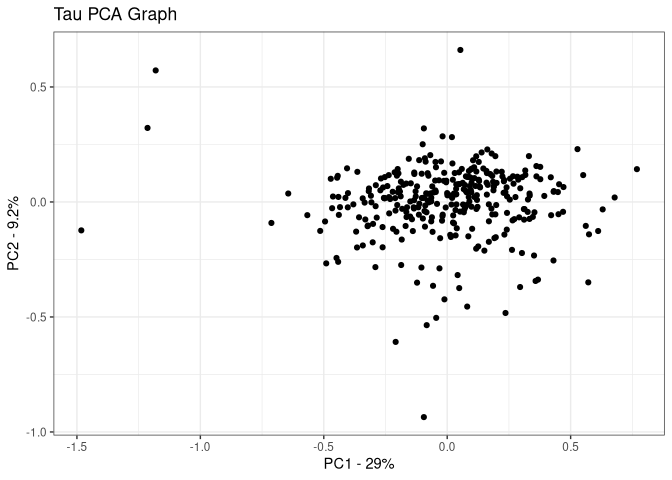

In [ ]:
## plot pc1 and pc2
plot(pca_tau$x[,1], pca_tau$x[,2])

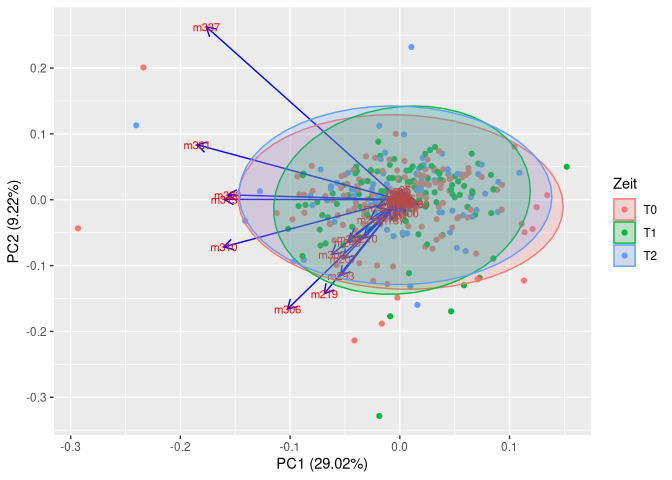

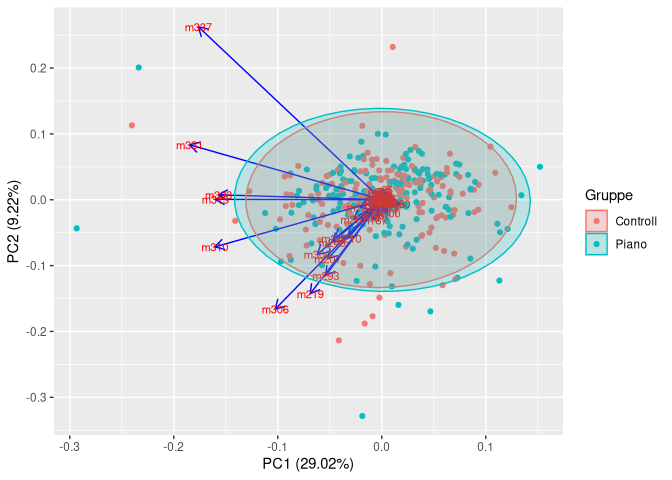

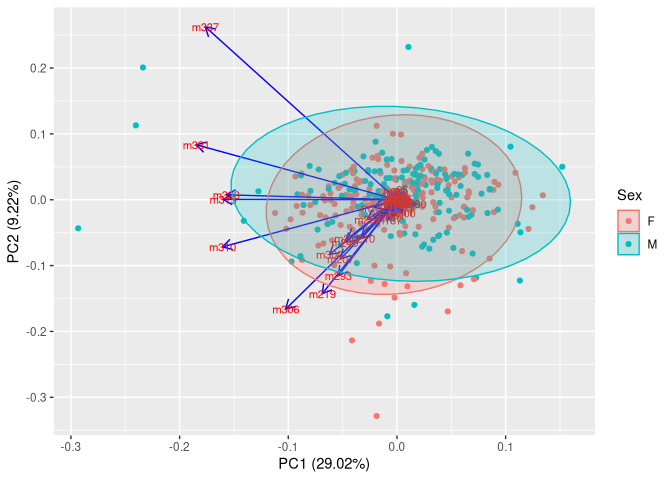

In [ ]:
library(ggfortify)
pca_tau_res <- prcomp(na.omit(tau[c(9:57)]), scale = FALSE)

autoplot(pca_tau_res, data = na.omit(tau[c(1:57)]), colour = 'Zeit',
         loadings = TRUE, loadings.colour = 'blue',
         loadings.label = TRUE, loadings.label.size = 3,
         frame = TRUE, frame.type = "norm"
         )

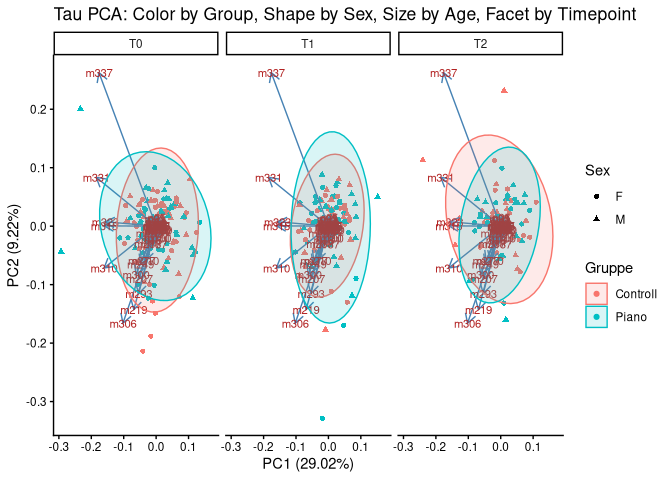

In [ ]:
autoplot(
  pca_tau_res,
  data = na.omit(tau[c(1:57,357)]),
  colour = "Gruppe",            # point color by group
  shape  = "Sex",               # point shape by sex
  loadings = TRUE,
  loadings.colour = "steelblue",        # <-- arrows
  loadings.label = TRUE,
  loadings.label.colour = "firebrick",  # <-- text labels
  loadings.label.size = 3,
  frame = TRUE,                 # << draw group frames
  frame.type = "norm",          # "norm", "t", or "convex"
  frame.level = 0.95,           # 95% ellipse
  frame.alpha = 0.15            # transparency for overlap
) +
  scale_shape_manual(values = c(16, 17)) +      # custom shapes for Sex
  scale_size_continuous(range = c(2, 6)) +      # min/max point size
  facet_wrap(~Zeit) +                       # separate panels for each timepoint
  theme_classic() +
  ggtitle("Tau PCA: Color by Group, Shape by Sex, Size by Age, Facet by Timepoint")

### Ranking Tau loadings

In [ ]:
# Rank CpGs by influence on PC1
ranked_tau_cpgs <- sort(abs(tau_loading_scores), decreasing = TRUE)
head(ranked_tau_cpgs)

     m331      m337      m310      m315      m323      m306 
0.4437532 0.4236060 0.3855752 0.3842794 0.3770694 0.2458814 

Die ersten 10 CpG scheinen die wesentlichen zu sein, wie in den Boxplots
zu erkennen! m277 = 0.1086290423  
m210 = 0.0785399456

| Rank | CpG  |        |
|------|------|-------:|
| 1    | m331 | 0.4438 |
| 2    | m337 | 0.4236 |
| 3    | m310 | 0.3856 |
| 4    | m315 | 0.3843 |
| 5    | m323 | 0.3771 |
| \-   | —-   |     —— |
| 6    | m306 | 0.2459 |
| 7    | m219 | 0.1652 |
| 8    | m300 | 0.1489 |
| 9    | m293 | 0.1295 |
| 10   | m207 | 0.1246 |
| 11   | m249 | 0.1151 |
| 12   | m277 | 0.1086 |
| 13   | m210 | 0.0785 |

### Visualize ranked loadings

There are two clear gaps:

Between m323 (0.377) and m306 (0.246) → Δ = 0.131

Between m277 (0.109) and m210 (0.079) → Δ = 0.030

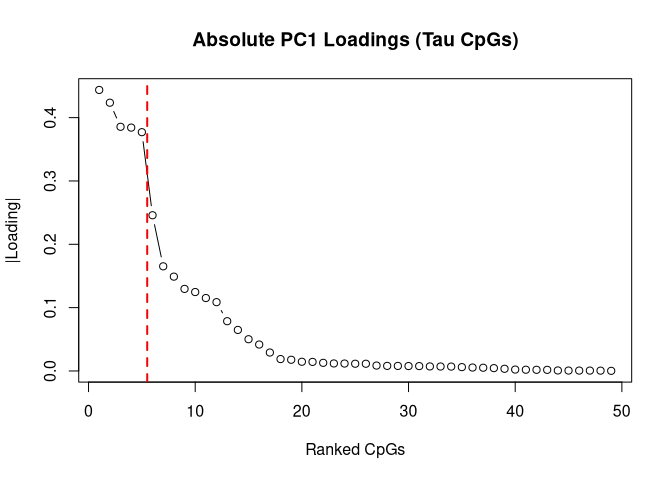

In [ ]:
plot(ranked_tau_cpgs, type = "b", main = "Absolute PC1 Loadings (Tau CpGs)",
     ylab = "|Loading|", xlab = "Ranked CpGs")
abline(v = 5.5, col = "red", lty = 2, lwd = 2)

## PSD95

In [ ]:
cpg_psd95 <- psd95[10:54]
pca_psd95 <- prcomp(na.omit(cpg_psd95), scale = FALSE)
pc_scores_psd95 <- as.data.frame(pca_psd95$x)

       PC      p_value       BH_adj
PC1   PC1 1.584142e-01 1.584142e-01
PC2   PC2 5.759325e-05 6.820254e-05
PC3   PC3 6.881611e-19 3.096725e-17
PC4   PC4 7.786528e-02 8.148692e-02
PC5   PC5 1.786288e-05 2.172512e-05
PC6   PC6 4.784385e-16 4.305946e-15
PC7   PC7 1.739137e-17 3.913059e-16
PC8   PC8 3.852559e-17 5.247959e-16
PC9   PC9 4.664852e-17 5.247959e-16
PC10 PC10 1.083834e-14 5.723025e-14
PC11 PC11 3.271486e-09 6.400734e-09
PC12 PC12 2.508505e-08 3.892507e-08
PC13 PC13 7.843143e-09 1.307190e-08
PC14 PC14 1.144605e-14 5.723025e-14
PC15 PC15 4.842577e-15 3.113085e-14
PC16 PC16 2.307318e-11 5.464701e-11
PC17 PC17 7.004795e-12 1.970099e-11
PC18 PC18 6.367541e-13 2.387828e-12
PC19 PC19 2.896933e-06 3.834176e-06
PC20 PC20 8.654725e-12 2.163681e-11
PC21 PC21 5.446160e-12 1.633848e-11
PC22 PC22 8.370331e-16 6.277748e-15
PC23 PC23 7.703699e-12 2.039215e-11
PC24 PC24 3.714835e-12 1.194054e-11
PC25 PC25 3.207999e-07 4.656773e-07
PC26 PC26 3.322703e-04 3.646869e-04
PC27 PC27 1.381444e-14 6.216

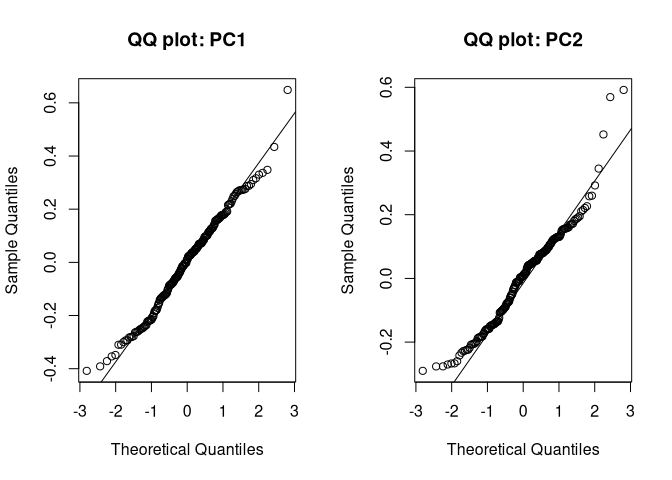

In [ ]:
## Normality diagnostics
# Perform Shapiro-Wilk test for normality on each principal component
shapiro_p_psd95 <- sapply(pc_scores_psd95, function(z) {
  n <- length(z)
  if (n >= 3 && n <= 5000) shapiro.test(z)$p.value else NA_real_
})
shapiro_tab_psd95 <- data.frame(PC = names(shapiro_p_psd95),
                          p_value = as.numeric(shapiro_p_psd95),
                          BH_adj = p.adjust(shapiro_p_psd95, method = "BH"))
print(shapiro_tab_psd95)

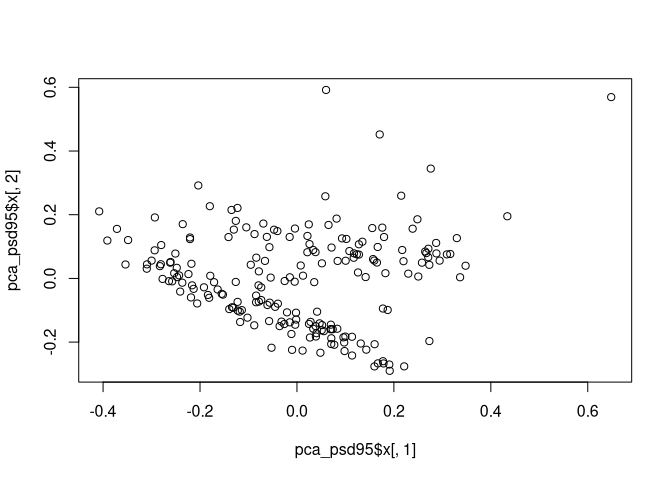

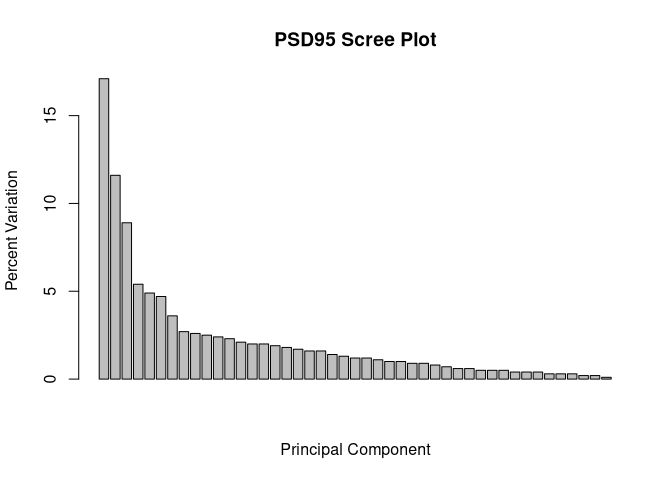

'data.frame':   201 obs. of  45 variables:
 $ PC1 : num  -0.2574 -0.1045 0.0335 -0.118 -0.0358 ...
 $ PC2 : num  -0.00925 0.16031 0.08933 -0.10431 -0.14987 ...
 $ PC3 : num  0.0784 0.0262 0.0471 0.0766 0.0793 ...
 $ PC4 : num  -0.0012 0.05588 0.14191 0.0383 0.00428 ...
 $ PC5 : num  -0.0685 -0.0908 0.0529 -0.0901 -0.0813 ...
 $ PC6 : num  -0.0382 0.0347 0.0286 0.033 0.0138 ...
 $ PC7 : num  0.0253 -0.0453 0.2938 0.0376 -0.0368 ...
 $ PC8 : num  -0.0142 0.0659 0.0899 0.032 0.0385 ...
 $ PC9 : num  0.00734 0.00928 -0.05404 -0.02025 0.0105 ...
 $ PC10: num  0.02627 -0.00241 -0.02189 -0.00871 0.02606 ...
 $ PC11: num  0.078547 -0.000995 -0.051691 -0.022701 -0.001995 ...
 $ PC12: num  0.013 -0.0554 -0.073 -0.0594 -0.0211 ...
 $ PC13: num  0.07574 -0.00836 0.01883 0.00824 0.00551 ...
 $ PC14: num  -0.08516 0.02439 0.00504 0.0182 -0.00596 ...
 $ PC15: num  0.0416 -0.01746 0.00878 -0.01195 0.03114 ...
 $ PC16: num  0.02084 0.00187 -0.03409 -0.01817 -0.01937 ...
 $ PC17: num  0.1818 -0.0341 -0.

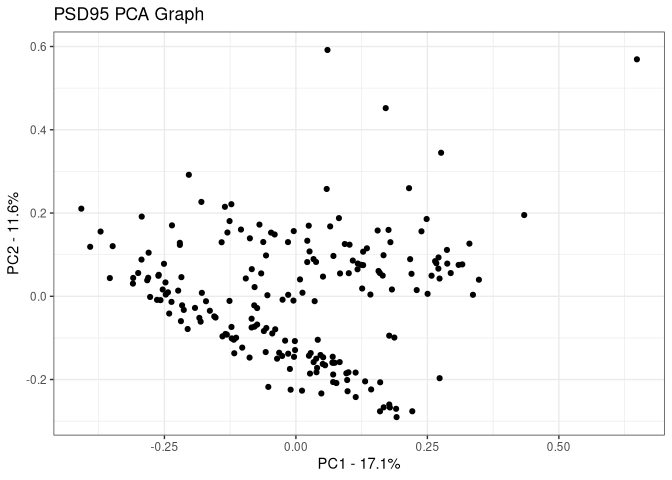

In [ ]:
## plot pc1 and pc2
plot(pca_psd95$x[,1], pca_psd95$x[,2])

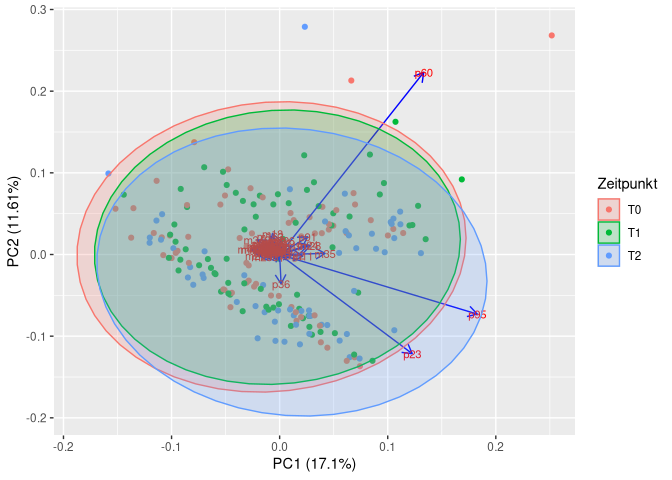

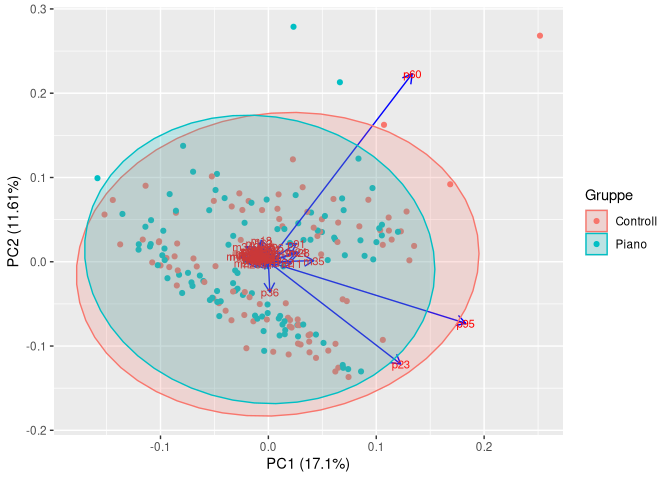

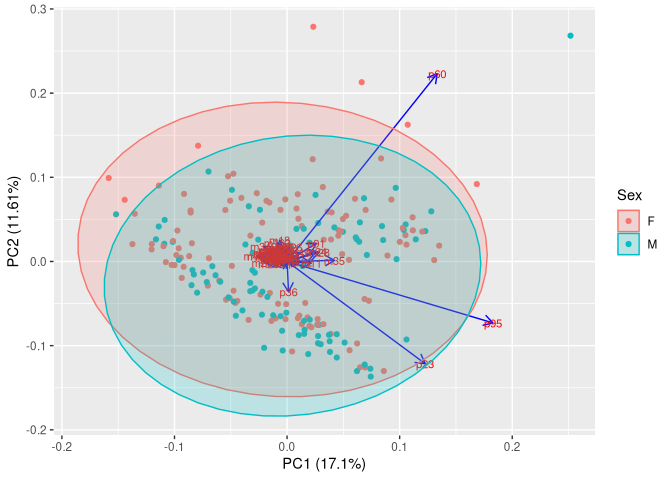

In [ ]:
library(ggfortify)
pca_psd95_res <- prcomp(na.omit(psd95[c(10:54)]), scale = FALSE)

autoplot(pca_psd95_res, data = na.omit(psd95[c(1:54)]), colour = 'Zeitpunkt',
         loadings = TRUE, loadings.colour = 'blue',
         loadings.label = TRUE, loadings.label.size = 3,
         frame = TRUE, frame.type = "norm"
         )

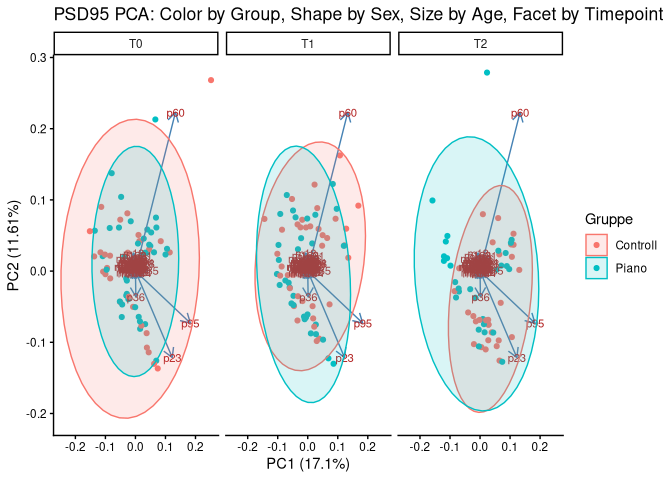

In [ ]:
autoplot(
  pca_psd95_res,
  data = na.omit(psd95[c(1:57,353)]),
  colour = "Gruppe",            # point color by group
  loadings = TRUE,
  loadings.colour = "steelblue",        # <-- arrows
  loadings.label = TRUE,
  loadings.label.colour = "firebrick",  # <-- text labels
  loadings.label.size = 3,
  frame = TRUE,                 # << draw group frames
  frame.type = "norm",          # "norm", "t", or "convex"
  frame.level = 0.95,           # 95% ellipse
  frame.alpha = 0.15            # transparency for overlap
) +
  scale_size_continuous(range = c(2, 6)) +      # min/max point size
  facet_wrap(~Zeitpunkt) +                       # separate panels for each timepoint
  theme_classic() +
  ggtitle("PSD95 PCA: Color by Group, Shape by Sex, Size by Age, Facet by Timepoint")

### Ranking PSD95 loadings

In [ ]:
# Rank CpGs by influence on PC1
ranked_psd95_cpgs <- sort(abs(psd95_loading_scores), decreasing = TRUE)
head(ranked_psd95_cpgs)

       p95        p60        p23        m35        m28       m418 
0.66395485 0.48408871 0.44524942 0.15257238 0.10348902 0.09661108 

| Rank | CpG  |       |
|------|------|------:|
| 1    | p95  | 0.664 |
| 2    | p60  | 0.484 |
| 3    | p23  | 0.445 |
| \-   | —    |    —– |
| 4    | m35  | 0.153 |
| 5    | m28  | 0.103 |
| 6    | m418 | 0.097 |
| 7    | m24  | 0.094 |
| 8    | p91  | 0.094 |
| 9    | m400 | 0.086 |
| 10   | m11  | 0.078 |

ChatGPT: What to report

“PC1 loadings show a sharp elbow after 3 CpGs (figure). We therefore
analyze the top-3 CpGs that explain the majority of variability and
provide sensitivity analyses using (i) all CpGs and (ii) a PC1-based
composite.”

### Visualize ranked loadings

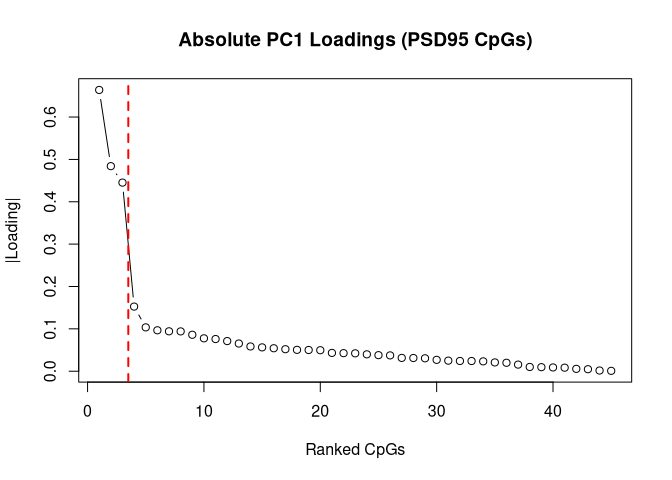

In [ ]:
#| label: fig-psd95-loadings
#| fig-cap: "Absolute PC1 Loadings (PSD95 CpGs)"
plot(ranked_psd95_cpgs, type = "b", main = "Absolute PC1 Loadings (PSD95 CpGs)",
     ylab = "|Loading|", xlab = "Ranked CpGs")
abline(v = 3.5, col = "red", lty = 2, lwd = 2)

Die ersten 3 CpG scheinen die wesentlichen zu sein, wie in den Boxplots
zu erkennen!

## all for manuscript figures

### biplot

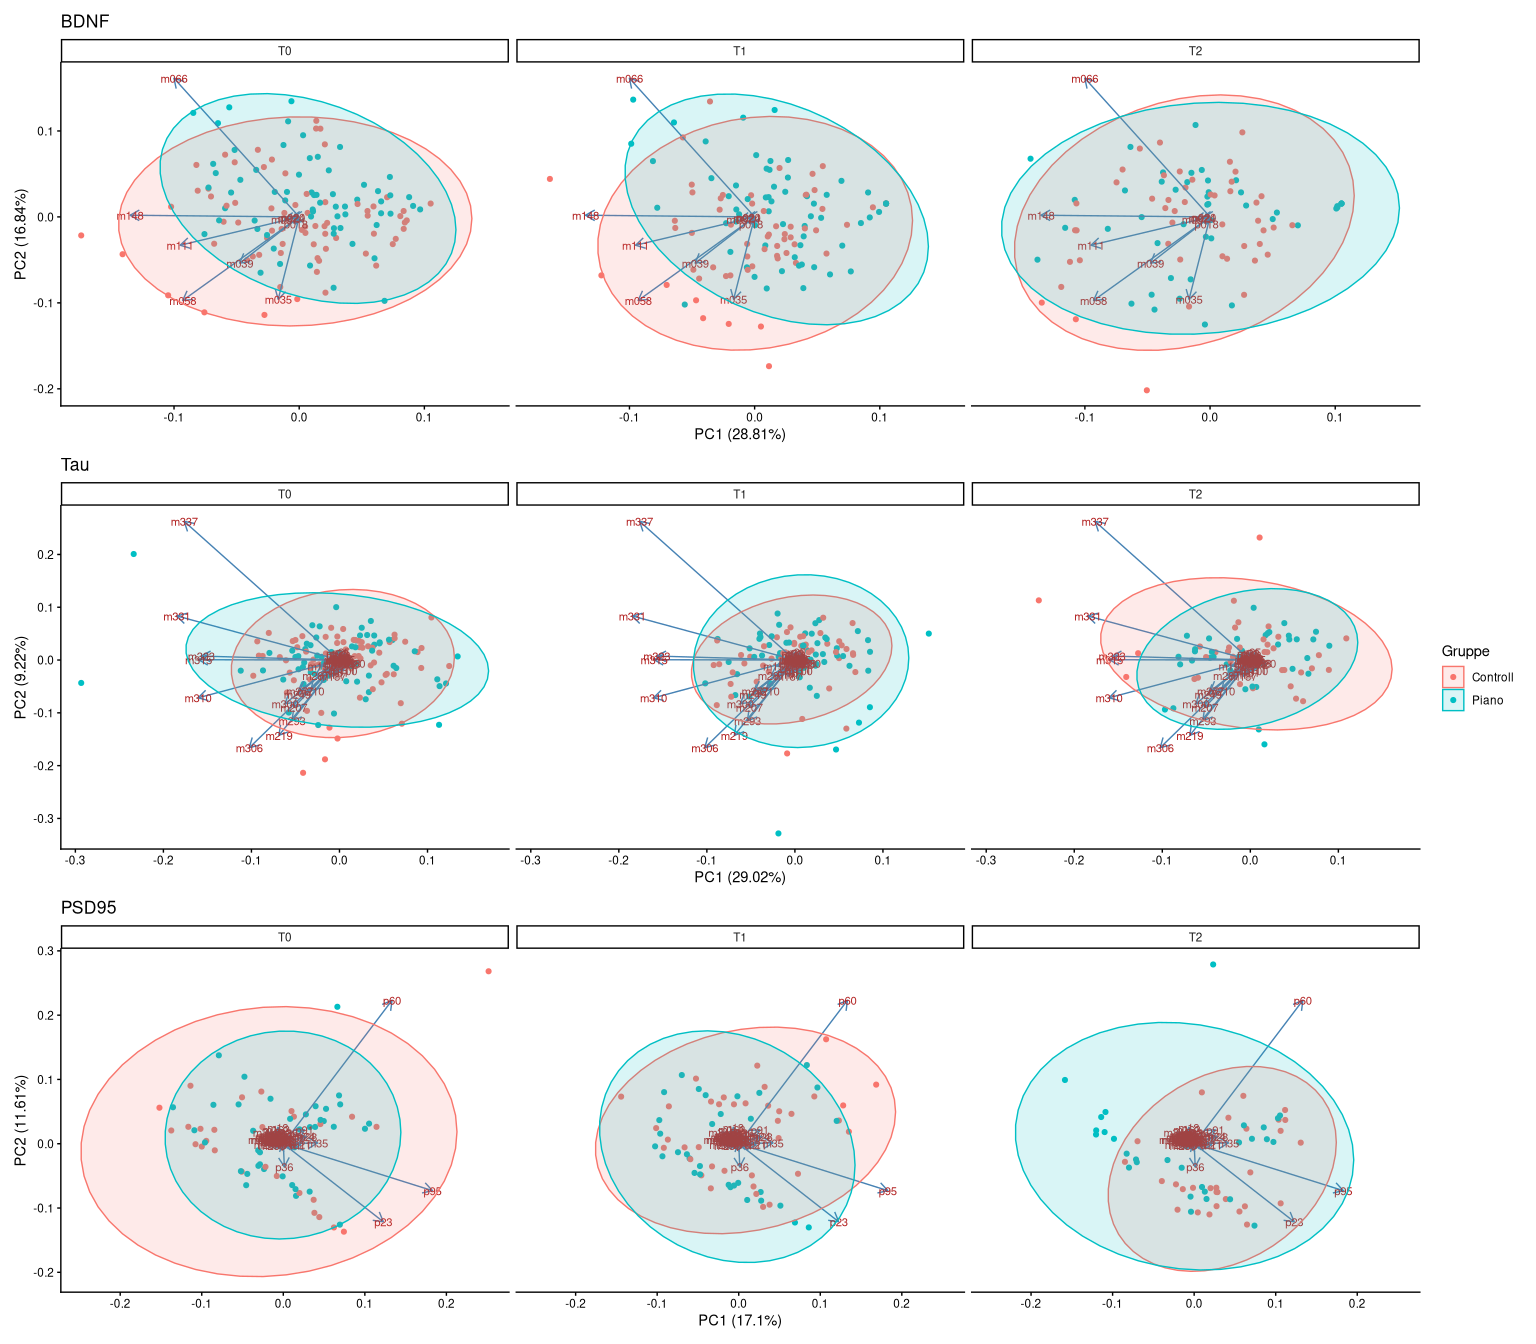

In [ ]:
#| label: fig-pca-genes
#| fig-cap: "PCA biplots for BDNF, Tau, and PSD95. Points colored by group; faceted by timepoint; loadings shown; 95% normal ellipses."
#| fig-width: 16
#| fig-height: 14

library(ggfortify)
library(ggplot2)
library(patchwork)

p_bdnf <- autoplot(
  pca_bdnf_res,
  data = na.omit(bdnf[1:22]),
  colour = "Gruppe",
  loadings = TRUE,
  loadings.colour = "steelblue",
  loadings.label = TRUE,
  loadings.label.colour = "firebrick",
  loadings.label.size = 3,
  frame = TRUE,
  frame.type = "norm",
  frame.level = 0.95,
  frame.alpha = 0.15
) +
  facet_wrap(~Zeitpunkt) +
  theme_classic() +
  labs(title = "BDNF")

p_tau <- autoplot(
  pca_tau_res,
  data = na.omit(tau[1:57]),
  colour = "Gruppe",
  loadings = TRUE,
  loadings.colour = "steelblue",
  loadings.label = TRUE,
  loadings.label.colour = "firebrick",
  loadings.label.size = 3,
  frame = TRUE,
  frame.type = "norm",
  frame.level = 0.95,
  frame.alpha = 0.15
) +
  facet_wrap(~Zeit) +   # keep your column name here
  theme_classic() +
  labs(title = "Tau")

p_psd95 <- autoplot(
  pca_psd95_res,
  data = na.omit(psd95[1:54]),
  colour = "Gruppe",
  loadings = TRUE,
  loadings.colour = "steelblue",
  loadings.label = TRUE,
  loadings.label.colour = "firebrick",
  loadings.label.size = 3,
  frame = TRUE,
  frame.type = "norm",
  frame.level = 0.95,
  frame.alpha = 0.15
) +
  facet_wrap(~Zeitpunkt) +
  theme_classic() +
  labs(title = "PSD95")

# combine into one figure (3 rows)
(p_bdnf / p_tau / p_psd95) +
  plot_layout(guides = "collect") &
  theme(legend.position = "right")

### Scree plots

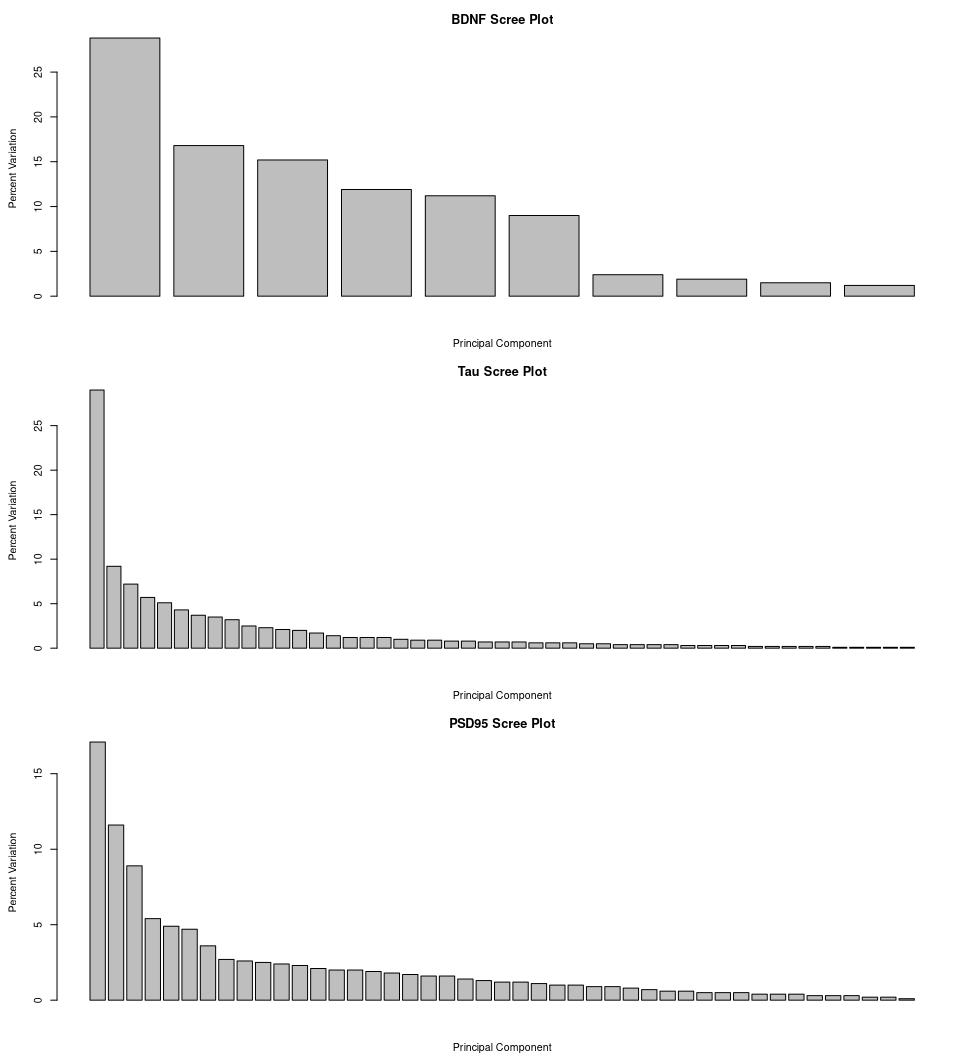

In [ ]:
#| label: fig-scree-all
#| fig-cap: "Scree plots showing percent variance explained by principal components for BDNF, Tau, and PSD95."
#| fig-width: 10
#| fig-height: 11

op <- par(no.readonly = TRUE)
par(mfrow = c(3, 1), mar = c(4.2, 4.5, 3, 1))

barplot(pca_bdnf_var_per,
        main = "BDNF Scree Plot",
        xlab = "Principal Component",
        ylab = "Percent Variation")

barplot(pca_tau_var_per,
        main = "Tau Scree Plot",
        xlab = "Principal Component",
        ylab = "Percent Variation")

barplot(pca_psd95_var_per,
        main = "PSD95 Scree Plot",
        xlab = "Principal Component",
        ylab = "Percent Variation")

par(op)

### loadings

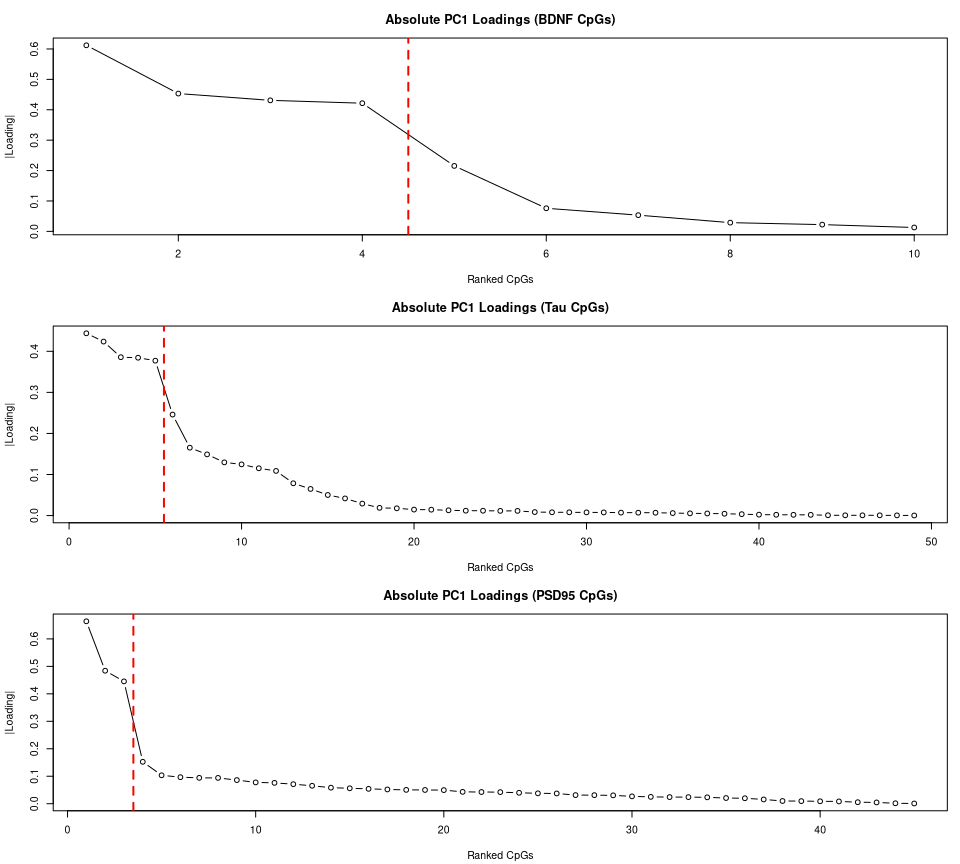

In [ ]:
#| label: fig-pc1-loadings
#| fig-cap: "Absolute PC1 loadings ranked for BDNF, Tau, and PSD95 CpGs. Red dashed line indicates the cutoff."
#| fig-width: 10
#| fig-height: 9

op <- par(no.readonly = TRUE)

par(
  mfrow = c(3, 1),          # 3 rows, 1 column
  mar   = c(4.2, 4.2, 3, 1) # margins: bottom, left, top, right
)

plot(ranked_bdnf_cpgs, type = "b",
     main = "Absolute PC1 Loadings (BDNF CpGs)",
     ylab = "|Loading|", xlab = "Ranked CpGs")
abline(v = 4.5, col = "red", lty = 2, lwd = 2)

plot(ranked_tau_cpgs, type = "b",
     main = "Absolute PC1 Loadings (Tau CpGs)",
     ylab = "|Loading|", xlab = "Ranked CpGs")
abline(v = 5.5, col = "red", lty = 2, lwd = 2)

plot(ranked_psd95_cpgs, type = "b",
     main = "Absolute PC1 Loadings (PSD95 CpGs)",
     ylab = "|Loading|", xlab = "Ranked CpGs")
abline(v = 3.5, col = "red", lty = 2, lwd = 2)

par(op)